In [1]:
# Cell 1: Imports and Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
from matplotlib.lines import Line2D

In [2]:
# Set style for README-ready visuals
plt.style.use('default')
sns.set_palette("husl")

# Create visualizations directory
import os
os.makedirs('visualizations', exist_ok=True)

In [4]:
# Load all datasets
df_monthly = pd.read_csv('output/uhi_monthly_analysis.csv')
df_yearly = pd.read_csv('output/uhi_yearly_trend.csv')
df_seasonal = pd.read_csv('output/uhi_seasonal_summary.csv')
df_zones = pd.read_csv('output/uhi_zone_summary.csv')
df_hotspots = pd.read_csv('output/uhi_hotspots.csv')
df_ghsl = pd.read_csv('output/ghsl_urban_structure.csv')

print("✅ All datasets loaded successfully!")
print(f"Monthly records: {len(df_monthly)}")
print(f"Yearly records: {len(df_yearly)}")
print(f"Hotspots: {len(df_hotspots)}")

✅ All datasets loaded successfully!
Monthly records: 61
Yearly records: 6
Hotspots: 10


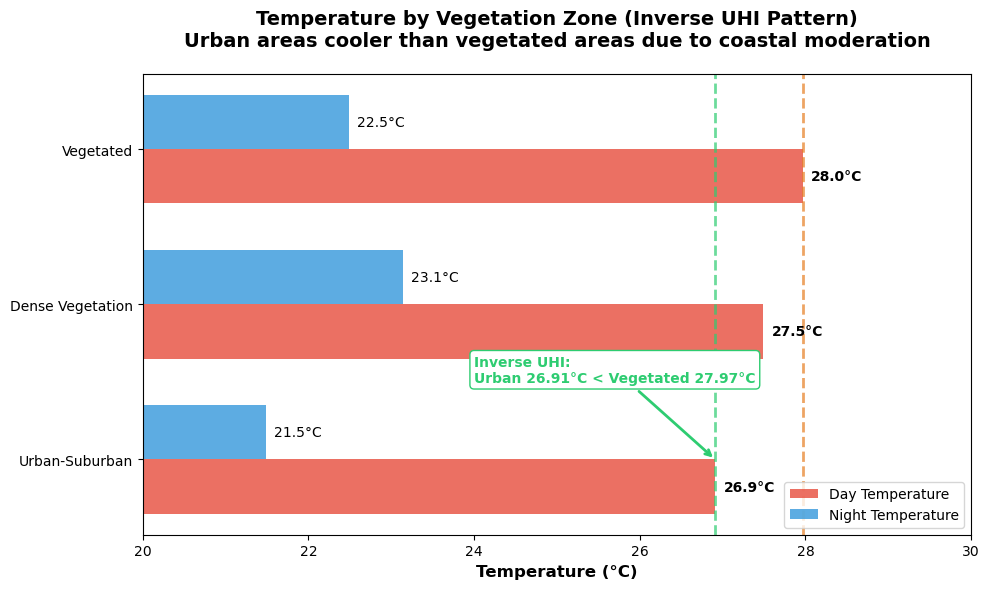

✅ Saved: 01_uhi_zone_comparison.png


In [5]:
# Cell 5: Chart 01 - UHI Zone Comparison (Horizontal Bar)
fig, ax = plt.subplots(figsize=(10, 6))

# Sort by day temperature for better visualization
df_zones_sorted = df_zones.sort_values('avg_day_temp_C', ascending=True)

y_pos = np.arange(len(df_zones_sorted))
height = 0.35

# Create horizontal bars
bars1 = ax.barh(y_pos - height/2, df_zones_sorted['avg_day_temp_C'], 
                height, label='Day Temperature', color='#e74c3c', alpha=0.8)
bars2 = ax.barh(y_pos + height/2, df_zones_sorted['avg_night_temp_C'], 
                height, label='Night Temperature', color='#3498db', alpha=0.8)

# Highlight inverse UHI pattern
ax.axvline(x=df_zones_sorted[df_zones_sorted['zone']=='Urban-Suburban']['avg_day_temp_C'].values[0], 
           color='#2ecc71', linestyle='--', linewidth=2, alpha=0.7)
ax.axvline(x=df_zones_sorted[df_zones_sorted['zone']=='Vegetated']['avg_day_temp_C'].values[0], 
           color='#e67e22', linestyle='--', linewidth=2, alpha=0.7)

# Add value labels
for i, (bar1, bar2) in enumerate(zip(bars1, bars2)):
    ax.text(bar1.get_width() + 0.1, bar1.get_y() + bar1.get_height()/2, 
            f'{bar1.get_width():.1f}°C', va='center', fontsize=10, fontweight='bold')
    ax.text(bar2.get_width() + 0.1, bar2.get_y() + bar2.get_height()/2, 
            f'{bar2.get_width():.1f}°C', va='center', fontsize=10)

ax.set_yticks(y_pos)
ax.set_yticklabels(df_zones_sorted['zone'])
ax.set_xlabel('Temperature (°C)', fontsize=12, fontweight='bold')
ax.set_title('Temperature by Vegetation Zone (Inverse UHI Pattern)\nUrban areas cooler than vegetated areas due to coastal moderation', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='lower right')
ax.set_xlim(20, 30)

# Add annotation
ax.annotate('Inverse UHI:\nUrban 26.91°C < Vegetated 27.97°C', 
            xy=(26.91, 0), xytext=(24, 0.5),
            arrowprops=dict(arrowstyle='->', color='#2ecc71', lw=2),
            fontsize=10, color='#2ecc71', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#2ecc71'))

plt.tight_layout()
plt.savefig('visualizations/01_uhi_zone_comparison.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()
print("✅ Saved: 01_uhi_zone_comparison.png")

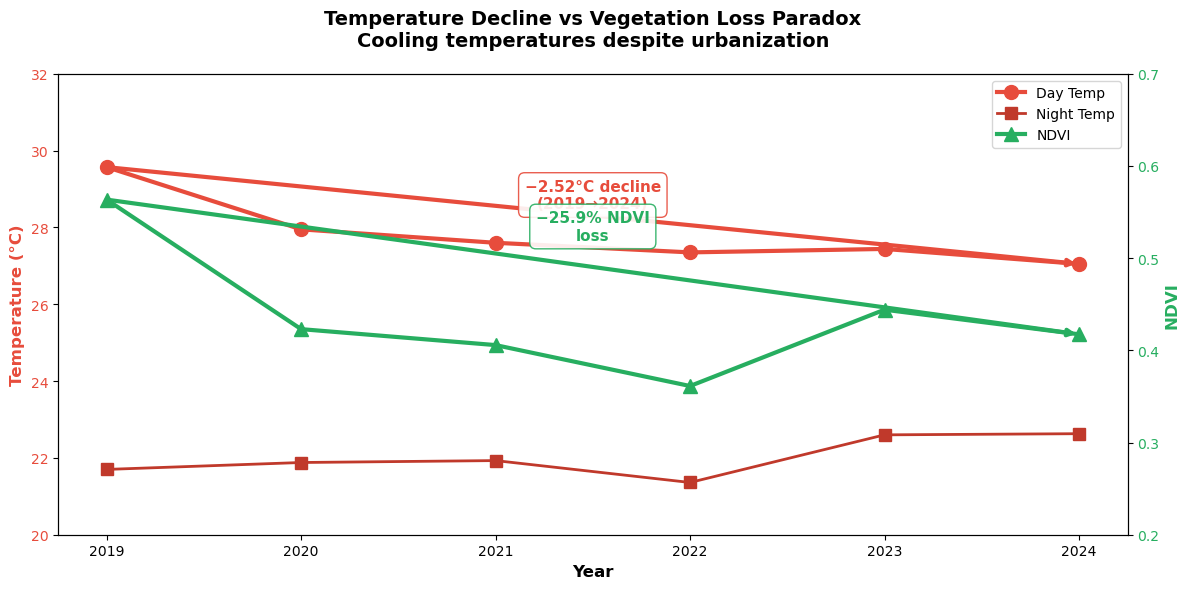

✅ Saved: 02_yearly_temperature_trend.png


In [6]:
# Cell 6: Chart 02 - Yearly Temperature Trend with NDVI (Dual Axis)
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary axis - Temperature
color1 = '#e74c3c'
ax1.set_xlabel('Year', fontsize=12, fontweight='bold')
ax1.set_ylabel('Temperature (°C)', color=color1, fontsize=12, fontweight='bold')
line1 = ax1.plot(df_yearly['year'], df_yearly['avg_day_temp_C'], 
                 color=color1, marker='o', linewidth=3, markersize=10, label='Day Temp')
line2 = ax1.plot(df_yearly['year'], df_yearly['avg_night_temp_C'], 
                 color='#c0392b', marker='s', linewidth=2, markersize=8, label='Night Temp')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_ylim(20, 32)

# Secondary axis - NDVI
ax2 = ax1.twinx()
color2 = '#27ae60'
ax2.set_ylabel('NDVI', color=color2, fontsize=12, fontweight='bold')
line3 = ax2.plot(df_yearly['year'], df_yearly['avg_ndvi'], 
                 color=color2, marker='^', linewidth=3, markersize=10, label='NDVI')
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(0.2, 0.7)

# Add cooling trend annotation
ax1.annotate('', xy=(2024, 27.05), xytext=(2019, 29.57),
             arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=3))
ax1.text(2021.5, 28.5, '−2.52°C decline\n(2019→2024)', fontsize=11, 
         fontweight='bold', color='#e74c3c', ha='center',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#e74c3c', alpha=0.9))

# Add NDVI decline annotation
ax2.annotate('', xy=(2024, 0.4174), xytext=(2019, 0.5635),
             arrowprops=dict(arrowstyle='->', color='#27ae60', lw=3))
ax2.text(2021.5, 0.52, '−25.9% NDVI\nloss', fontsize=11, 
         fontweight='bold', color='#27ae60', ha='center',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#27ae60', alpha=0.9))

# Combine legends
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')

plt.title('Temperature Decline vs Vegetation Loss Paradox\nCooling temperatures despite urbanization', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('visualizations/02_yearly_temperature_trend.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print("✅ Saved: 02_yearly_temperature_trend.png")

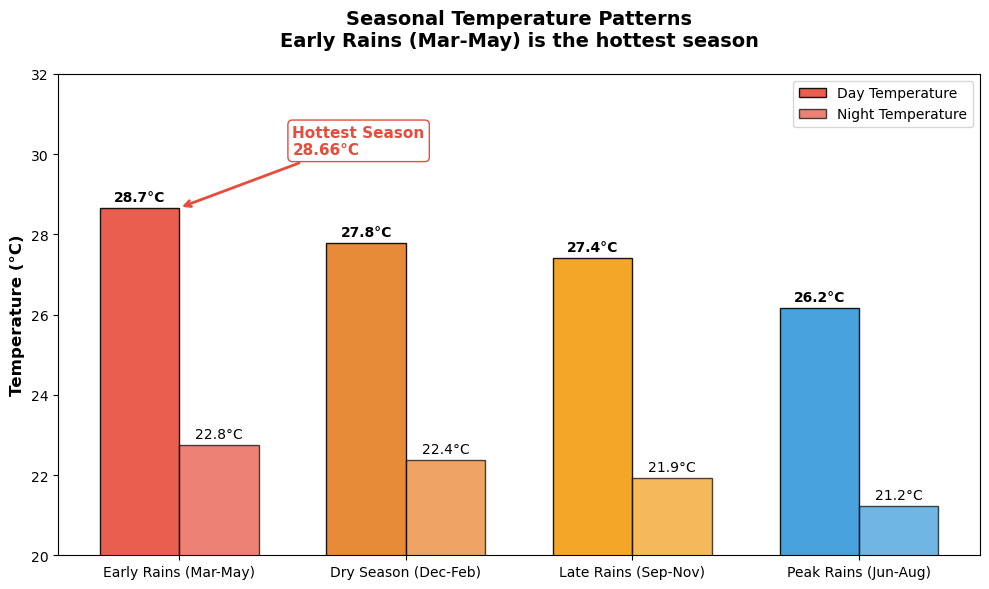

✅ Saved: 03_seasonal_temperature.png


In [7]:
# Cell 7: Chart 03 - Seasonal Temperature (Sorted Bar)
fig, ax = plt.subplots(figsize=(10, 6))

# Sort by day temperature (hottest first)
df_seasonal_sorted = df_seasonal.sort_values('avg_day_temp_C', ascending=False)

# Color gradient from hot to cool
colors = ['#e74c3c', '#e67e22', '#f39c12', '#3498db']

x_pos = np.arange(len(df_seasonal_sorted))
width = 0.35

bars1 = ax.bar(x_pos - width/2, df_seasonal_sorted['avg_day_temp_C'], 
               width, label='Day Temperature', color=colors, alpha=0.9, edgecolor='black')
bars2 = ax.bar(x_pos + width/2, df_seasonal_sorted['avg_night_temp_C'], 
               width, label='Night Temperature', color=[c + '80' for c in colors], 
               alpha=0.7, edgecolor='black')

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
            f'{height:.1f}°C', ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
            f'{height:.1f}°C', ha='center', va='bottom', fontsize=10)

ax.set_xticks(x_pos)
ax.set_xticklabels(df_seasonal_sorted['season'], rotation=0, ha='center')
ax.set_ylabel('Temperature (°C)', fontsize=12, fontweight='bold')
ax.set_title('Seasonal Temperature Patterns\nEarly Rains (Mar-May) is the hottest season', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend()
ax.set_ylim(20, 32)

# Highlight Early Rains
ax.annotate('Hottest Season\n28.66°C', xy=(0, 28.66), xytext=(0.5, 30),
            arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=2),
            fontsize=11, fontweight='bold', color='#e74c3c',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#e74c3c'))

plt.tight_layout()
plt.savefig('visualizations/03_seasonal_temperature.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print("✅ Saved: 03_seasonal_temperature.png")

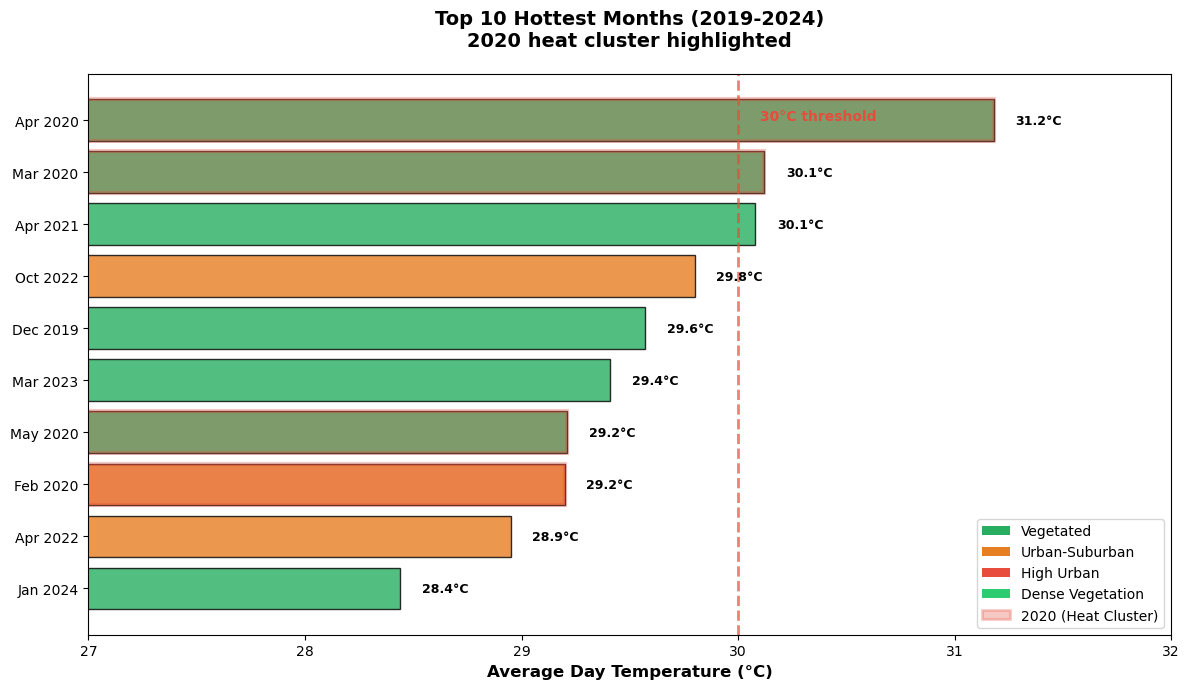

✅ Saved: 04_hotspots_2020_cluster.png


In [8]:
# Cell 8: Chart 04 - Hotspots 2020 Cluster
fig, ax = plt.subplots(figsize=(12, 7))

# Create period label
df_hotspots['period'] = df_hotspots['month'].map({
    1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
    7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'
}) + ' ' + df_hotspots['year'].astype(str)

# Sort by temperature for horizontal bar
df_hotspots_sorted = df_hotspots.sort_values('avg_lst_day', ascending=True)

# Color by zone
zone_colors = {'Vegetated': '#27ae60', 'Urban-Suburban': '#e67e22', 
               'High Urban': '#e74c3c', 'Dense Vegetation': '#2ecc71'}
colors = [zone_colors.get(z, '#95a5a6') for z in df_hotspots_sorted['zone']]

bars = ax.barh(range(len(df_hotspots_sorted)), df_hotspots_sorted['avg_lst_day'], 
               color=colors, alpha=0.8, edgecolor='black')

# Add value labels
for i, (bar, temp) in enumerate(zip(bars, df_hotspots_sorted['avg_lst_day'])):
    ax.text(temp + 0.1, bar.get_y() + bar.get_height()/2, 
            f'{temp:.1f}°C', va='center', fontsize=9, fontweight='bold')

ax.set_yticks(range(len(df_hotspots_sorted)))
ax.set_yticklabels(df_hotspots_sorted['period'])
ax.set_xlabel('Average Day Temperature (°C)', fontsize=12, fontweight='bold')
ax.set_title('Top 10 Hottest Months (2019-2024)\n2020 heat cluster highlighted', 
             fontsize=14, fontweight='bold', pad=20)

# Add 30°C threshold line
ax.axvline(x=30, color='#e74c3c', linestyle='--', linewidth=2, alpha=0.7)
ax.text(30.1, 9, '30°C threshold', fontsize=10, color='#e74c3c', fontweight='bold')

# Highlight 2020 entries
for i, row in df_hotspots_sorted.iterrows():
    if row['year'] == 2020:
        ax.barh(df_hotspots_sorted.index.get_loc(i), row['avg_lst_day'], 
                color='#e74c3c', alpha=0.3, edgecolor='#e74c3c', linewidth=3)

# Legend
legend_elements = [mpatches.Patch(facecolor=zone_colors[z], label=z) for z in zone_colors]
legend_elements.append(mpatches.Patch(facecolor='#e74c3c', alpha=0.3, edgecolor='#e74c3c', 
                                      linewidth=2, label='2020 (Heat Cluster)'))
ax.legend(handles=legend_elements, loc='lower right')

ax.set_xlim(27, 32)
plt.tight_layout()
plt.savefig('visualizations/04_hotspots_2020_cluster.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print("✅ Saved: 04_hotspots_2020_cluster.png")

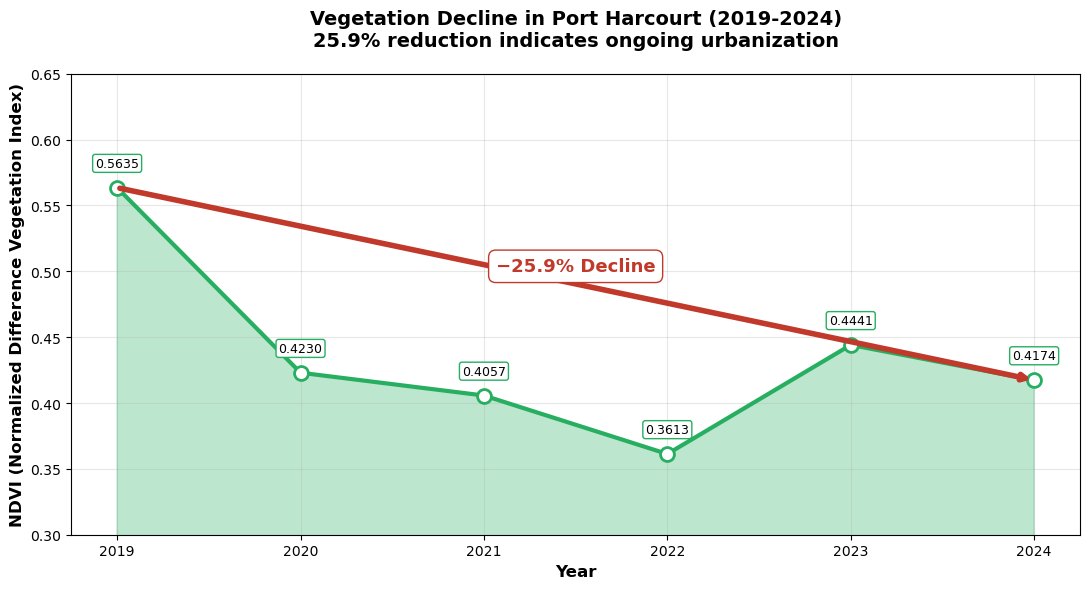

✅ Saved: 05_ndvi_decline_trend.png


In [9]:
# Cell 9: Chart 05 - NDVI Decline Trend
fig, ax = plt.subplots(figsize=(11, 6))

# Area fill under line
ax.fill_between(df_yearly['year'], df_yearly['avg_ndvi'], alpha=0.3, color='#27ae60')
ax.plot(df_yearly['year'], df_yearly['avg_ndvi'], color='#27ae60', 
        marker='o', linewidth=3, markersize=10, markerfacecolor='white', 
        markeredgewidth=2, markeredgecolor='#27ae60')

# Add points with values
for year, ndvi in zip(df_yearly['year'], df_yearly['avg_ndvi']):
    ax.annotate(f'{ndvi:.4f}', xy=(year, ndvi), xytext=(0, 15),
                textcoords='offset points', ha='center', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='#27ae60'))

ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('NDVI (Normalized Difference Vegetation Index)', fontsize=12, fontweight='bold')
ax.set_title('Vegetation Decline in Port Harcourt (2019-2024)\n25.9% reduction indicates ongoing urbanization', 
             fontsize=14, fontweight='bold', pad=20)

# Add decline arrow
ax.annotate('', xy=(2024, 0.4174), xytext=(2019, 0.5635),
            arrowprops=dict(arrowstyle='->', color='#c0392b', lw=4))
ax.text(2021.5, 0.5, '−25.9% Decline', fontsize=13, fontweight='bold', 
        color='#c0392b', ha='center',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#c0392b'))

ax.set_ylim(0.3, 0.65)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('visualizations/05_ndvi_decline_trend.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print("✅ Saved: 05_ndvi_decline_trend.png")

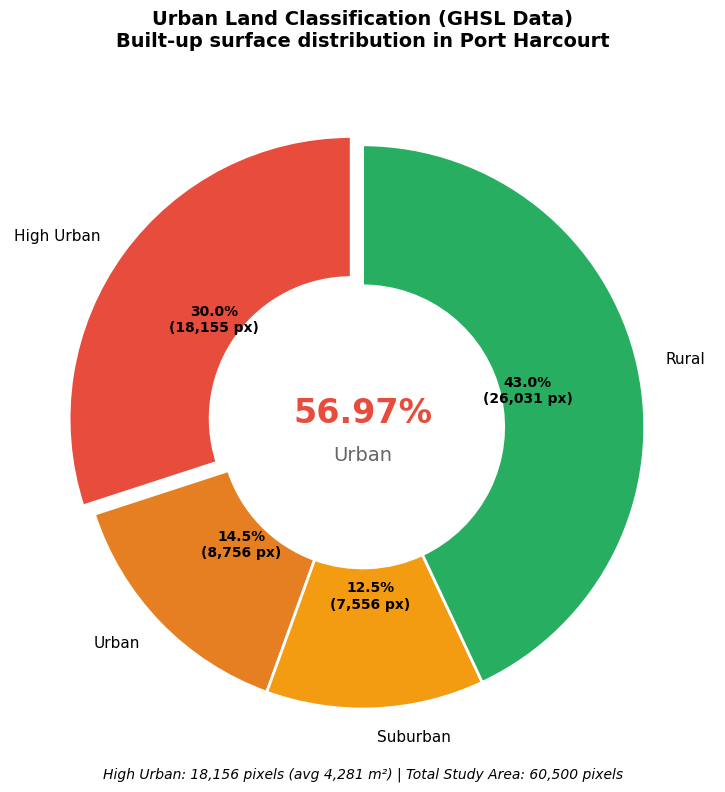

✅ Saved: 06_urban_coverage_donut.png
NOTEBOOK 1 COMPLETE - All 6 charts generated!

Generated files in 'visualizations/' folder:
  ✅ 01_uhi_zone_comparison.png
  ✅ 02_yearly_temperature_trend.png
  ✅ 03_seasonal_temperature.png
  ✅ 04_hotspots_2020_cluster.png
  ✅ 05_ndvi_decline_trend.png
  ✅ 06_urban_coverage_donut.png


In [10]:
# Cell 10: Chart 06 - Urban Coverage (Donut Chart - improved from pie)
fig, ax = plt.subplots(figsize=(10, 8))

# Calculate percentages
total = df_ghsl['pixel_count'].sum()
df_ghsl['percentage'] = (df_ghsl['pixel_count'] / total * 100).round(2)

# Colors
colors = ['#e74c3c', '#e67e22', '#f39c12', '#27ae60']
explode = (0.05, 0, 0, 0)  # Explode High Urban

# Create donut chart
wedges, texts, autotexts = ax.pie(df_ghsl['pixel_count'], 
                                    labels=df_ghsl['urban_class'],
                                    colors=colors,
                                    explode=explode,
                                    autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100*total):,} px)',
                                    startangle=90,
                                    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2),
                                    textprops=dict(fontsize=11))

# Enhance text
for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')

# Center text
centre_circle = plt.Circle((0, 0), 0.3, fc='white')
ax.add_artist(centre_circle)
ax.text(0, 0.05, '56.97%', ha='center', va='center', fontsize=24, fontweight='bold', color='#e74c3c')
ax.text(0, -0.1, 'Urban', ha='center', va='center', fontsize=14, color='#666')

ax.set_title('Urban Land Classification (GHSL Data)\nBuilt-up surface distribution in Port Harcourt', 
             fontsize=14, fontweight='bold', pad=20)

# Add table with details
table_data = []
for _, row in df_ghsl.iterrows():
    table_data.append([row['urban_class'], f"{row['pixel_count']:,}", 
                       f"{row['avg_built_up_m2']:,.0f} m²"])

plt.figtext(0.5, 0.02, 'High Urban: 18,156 pixels (avg 4,281 m²) | Total Study Area: 60,500 pixels', 
            ha='center', fontsize=10, style='italic')

plt.tight_layout()
plt.savefig('visualizations/06_urban_coverage_donut.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print("✅ Saved: 06_urban_coverage_donut.png")


# Cell 8: Summary
print("="*60)
print("NOTEBOOK 1 COMPLETE - All 6 charts generated!")
print("="*60)
print("\nGenerated files in 'visualizations/' folder:")
for f in ['01_uhi_zone_comparison.png', '02_yearly_temperature_trend.png',
          '03_seasonal_temperature.png', '04_hotspots_2020_cluster.png',
          '05_ndvi_decline_trend.png', '06_urban_coverage_donut.png']:
    print(f"  ✅ {f}")